# Data Observation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
REGIONS_NUMBER = 3108

TRAIN_DAYS_NUMBER = 5480
TEST_DAYS_NUMBER = 91

In [3]:
def file_csv_to_df(train):
    name = "train" if train else "test"
    df = pd.read_csv(f"data/{name}.csv")

    numeric_cols = [
        "tmp", "tmp_min", "tmp_max", "tmp_range",
        "wind", "wind_min", "wind_max", "wind_range",
        "surf_tmp", 
        "surf_pre",
        "dp_tmp", "wb_tmp",
        "prec"
    ]
    if (train):
        numeric_cols.append("score")

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Fill NaN scores with the last day's score in each 7-row week
    if (train):
        df["score"] = df.groupby(df.index // 7)["score"].transform(lambda s: s.bfill())

    return df

def region_df(df, region_id):
    assert 1 <= int(region_id[1:]) and int(region_id[1:]) <= REGIONS_NUMBER
    
    return df[df['region_id'] == region_id]

In [30]:
def data_frame_to_figures(df):
    df = df.sort_values("date").reset_index(drop=True)

    fig, axes = plt.subplots(6, 1, sharex=True, figsize=(15, 8))

    x = list(range(len(df)))
    dates = df["date"].tolist()

    drought_colors = [
        "#fff7ec",
        "#fee8c8",
        "#fdd49e",
        "#fdbb84",
        "#fc8d59",
        "#b30000",
    ]

    if "score" in df.columns:
        score = df["score"].fillna(0).astype(int).clip(0, 5)
    else:
        score = None

    def add_drought_background(ax):
        if score is None:
            return
        for i in range(len(x) - 1):
            ax.axvspan(
                x[i],
                x[i + 1],
                color=drought_colors[score.iloc[i]],
                alpha=0.7,
                lw=0,
                zorder=0,
            )

    # Temperature
    ax = axes[0]
    add_drought_background(ax)
    ax.plot(x, df["tmp"], color="red", label="mean", lw=0.5, zorder=1, alpha=0.7)
    ax.plot(x, df["tmp_range"], color="orange", label="range", lw=0.5, zorder=1, alpha=0.7)
    ax.fill_between(x, df["tmp_min"], df["tmp_max"], color="red", alpha=0.2, label="min/max", zorder=1)
    ax.set_title("Temperature")
    ax.legend()

    # Wind
    ax = axes[1]
    add_drought_background(ax)
    ax.plot(x, df["wind"], color="blue", label="mean", lw=0.5, zorder=1, alpha=0.7)
    ax.plot(x, df["wind_range"], color="green", label="range", lw=0.5, zorder=1, alpha=0.7)
    ax.fill_between(x, df["wind_min"], df["wind_max"], color="blue", alpha=0.2, label="min/max", zorder=1)
    ax.set_title("Wind Speed")
    ax.legend()

    # Surface temperature
    ax = axes[2]
    add_drought_background(ax)
    ax.plot(x, df["surf_tmp"], color="gold", lw=0.5, zorder=1)
    ax.set_title("Surface Temperature")

    # Surface pressure
    ax = axes[3]
    add_drought_background(ax)
    ax.plot(x, df["surf_pre"], color="gold", lw=0.5, zorder=1)
    ax.set_title("Surface Pressure")

    # Dew point / wet bulb
    ax = axes[4]
    add_drought_background(ax)
    ax.plot(x, df["dp_tmp"], color="blue", label="dp", lw=0.5, zorder=1, alpha=0.5)
    ax.plot(x, df["wb_tmp"], color="red", label="wb", lw=0.5, zorder=1, alpha=0.5)
    ax.set_title("Dew Point / Wet Bulb Temperature")
    ax.legend()

    # Precipitation
    ax = axes[5]
    add_drought_background(ax)
    ax.plot(x, df["prec"], color="blue", lw=0.5, zorder=1)
    ax.set_title("Precipitation")

    # Show only a few x labels
    tick_positions = [i * len(x) // 13 for i in range(13)] + [len(x) - 1]

    tick_positions = list(dict.fromkeys(tick_positions))
    tick_labels = [dates[i] for i in tick_positions]

    axes[-1].set_xticks(tick_positions)
    axes[-1].set_xticklabels(tick_labels, rotation=45, ha="right")

    # Drought legend at the bottom
    drought_handles = [
        Patch(facecolor=drought_colors[i], edgecolor="none", alpha=0.6, label=f"score {i}")
        for i in range(6)
    ]
    fig.legend(
        handles=drought_handles,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(0.5, -0.025),
        title="Drought score",
        frameon=False,
    )
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

In [5]:
df = file_csv_to_df(True)
df.head()

,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.27,3.76,5.89,-0.14,-0.11,14.87,-2.37,17.24,4.23,1.45,2.58,0.24,2.34,0.0
1,R1,3005-01-01,0.00,101.26,5.37,8.81,4.59,4.60,17.28,1.14,16.14,7.96,1.83,2.38,1.18,1.21,0.0
2,R1,3005-01-02,0.01,100.81,9.32,13.09,12.74,12.74,17.38,8.21,9.17,12.96,1.96,2.49,1.39,1.09,0.0
3,R1,3005-01-03,0.02,100.51,11.40,16.01,16.08,16.08,19.24,13.77,5.47,15.82,2.13,2.67,1.74,0.93,0.0
4,R1,3005-01-04,1.93,100.16,12.20,17.98,17.04,17.04,22.85,14.27,8.58,17.86,2.91,4.25,2.13,2.11,0.0


In [6]:
df_1 = region_df(df, 'R1')
df_1.head()

,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.27,3.76,5.89,-0.14,-0.11,14.87,-2.37,17.24,4.23,1.45,2.58,0.24,2.34,0.0
1,R1,3005-01-01,0.00,101.26,5.37,8.81,4.59,4.60,17.28,1.14,16.14,7.96,1.83,2.38,1.18,1.21,0.0
2,R1,3005-01-02,0.01,100.81,9.32,13.09,12.74,12.74,17.38,8.21,9.17,12.96,1.96,2.49,1.39,1.09,0.0
3,R1,3005-01-03,0.02,100.51,11.40,16.01,16.08,16.08,19.24,13.77,5.47,15.82,2.13,2.67,1.74,0.93,0.0
4,R1,3005-01-04,1.93,100.16,12.20,17.98,17.04,17.04,22.85,14.27,8.58,17.86,2.91,4.25,2.13,2.11,0.0


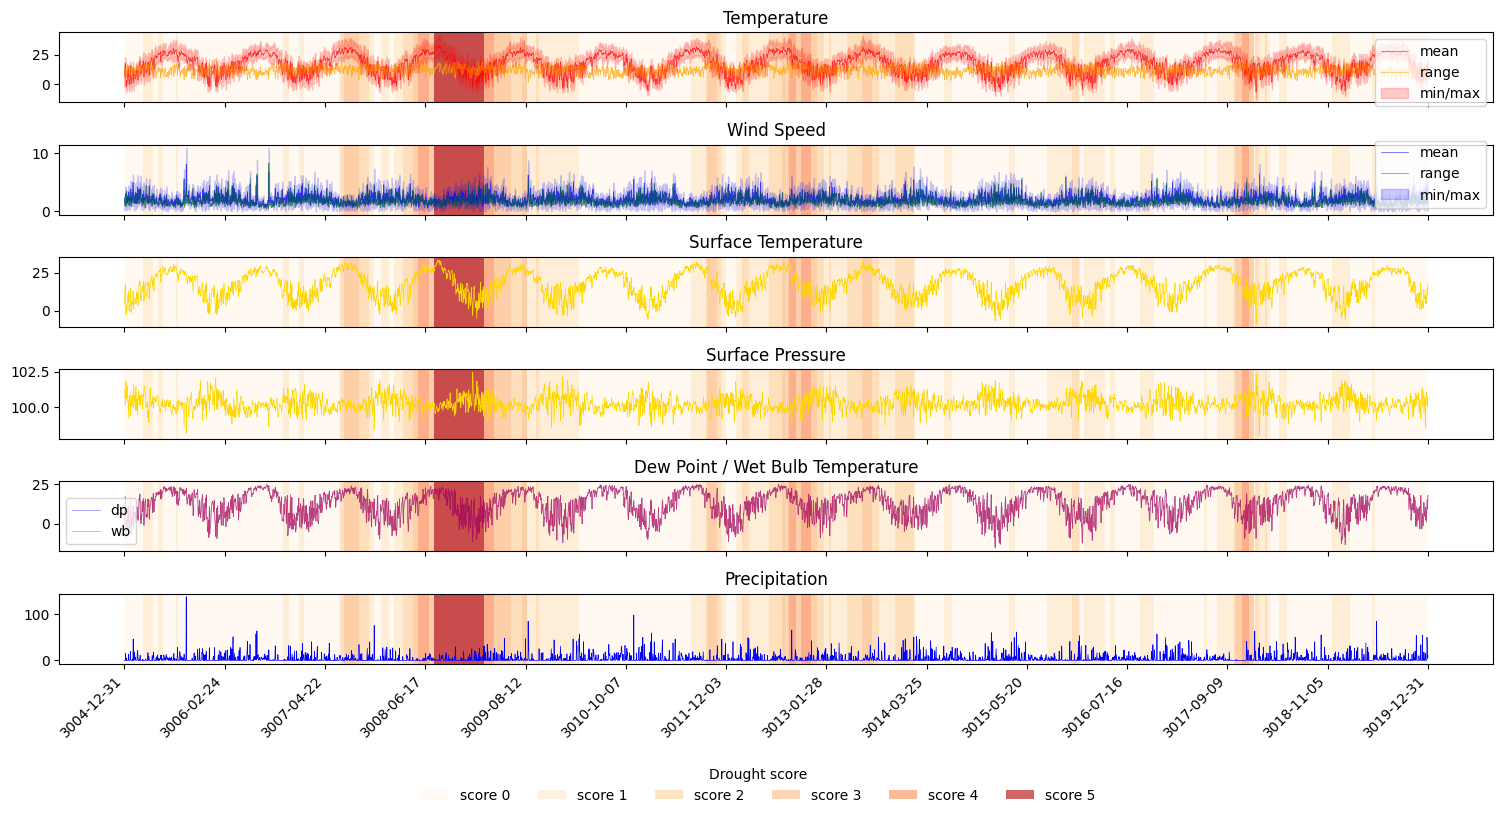

In [31]:
data_frame_to_figures(df_1)

In [26]:
seen = [False for _ in range(6)]
df_list = [None for _ in range(6)]

i = 0
cnt = 0

while cnt < 6 and 7 * i + 6 < len(df):
    df_i = df.iloc[7 * i : 7 * i + 21].copy()

    label = int(df_i["score"].dropna().iloc[-20])  # last non-NaN score in the week

    if not seen[label]:
        df_list[label] = df_i
        seen[label] = True
        cnt += 1

        print(
            f"region: {df_i['region_id'].iloc[0]} | "
            f"date: {df_i['date'].iloc[0]} -> {df_i['date'].iloc[-1]} | "
            f"score: {label}"
        )

    i += 1

region: R1 | date: 3004-12-31 -> 3005-01-20 | score: 0
region: R1 | date: 3005-03-17 -> 3005-04-06 | score: 1
region: R1 | date: 3007-06-28 -> 3007-07-18 | score: 2
region: R1 | date: 3007-07-12 -> 3007-08-01 | score: 3
region: R1 | date: 3008-05-16 -> 3008-06-05 | score: 4
region: R1 | date: 3008-07-25 -> 3008-08-14 | score: 5


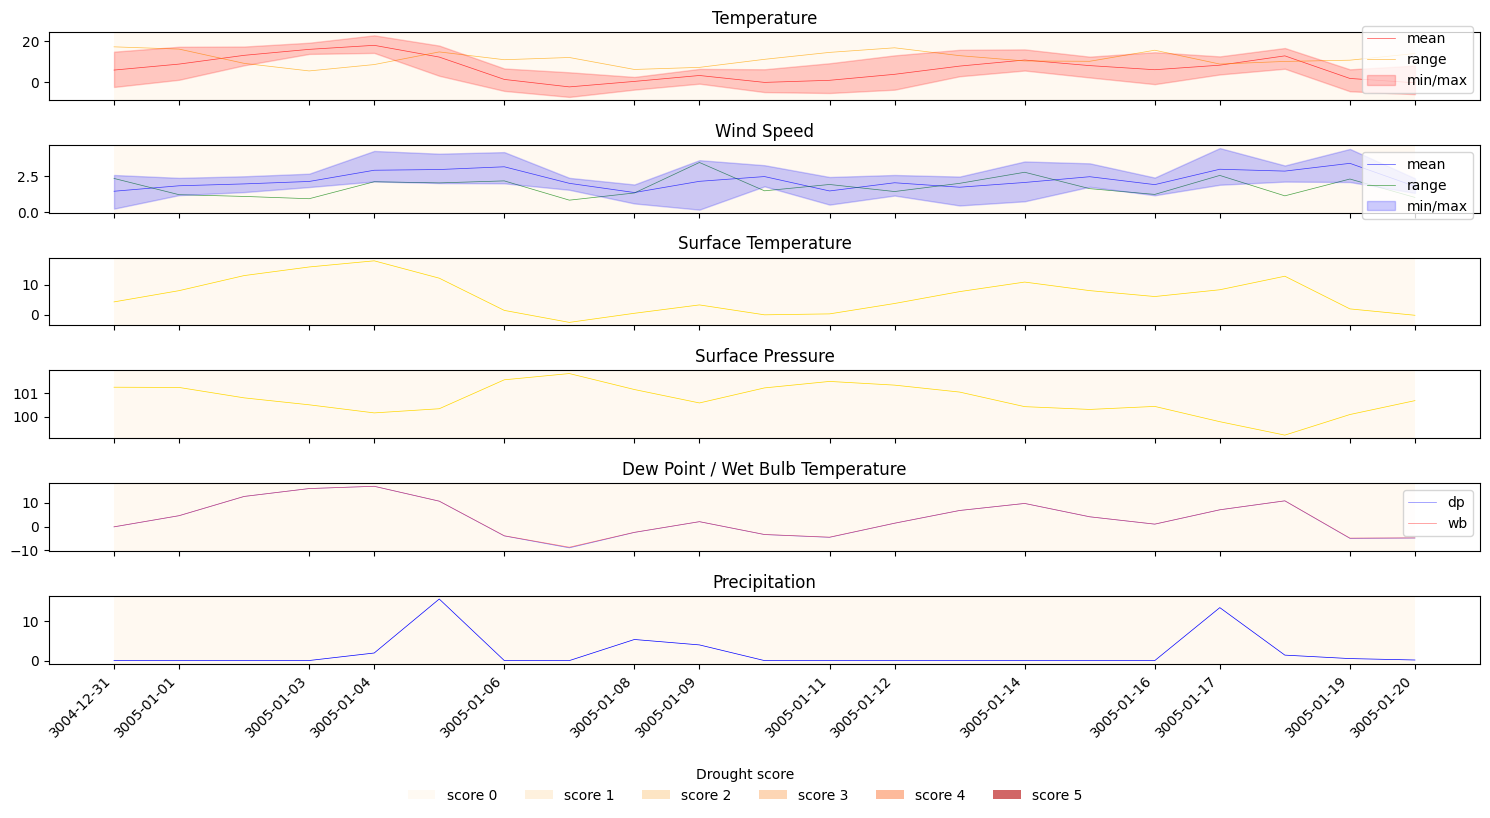

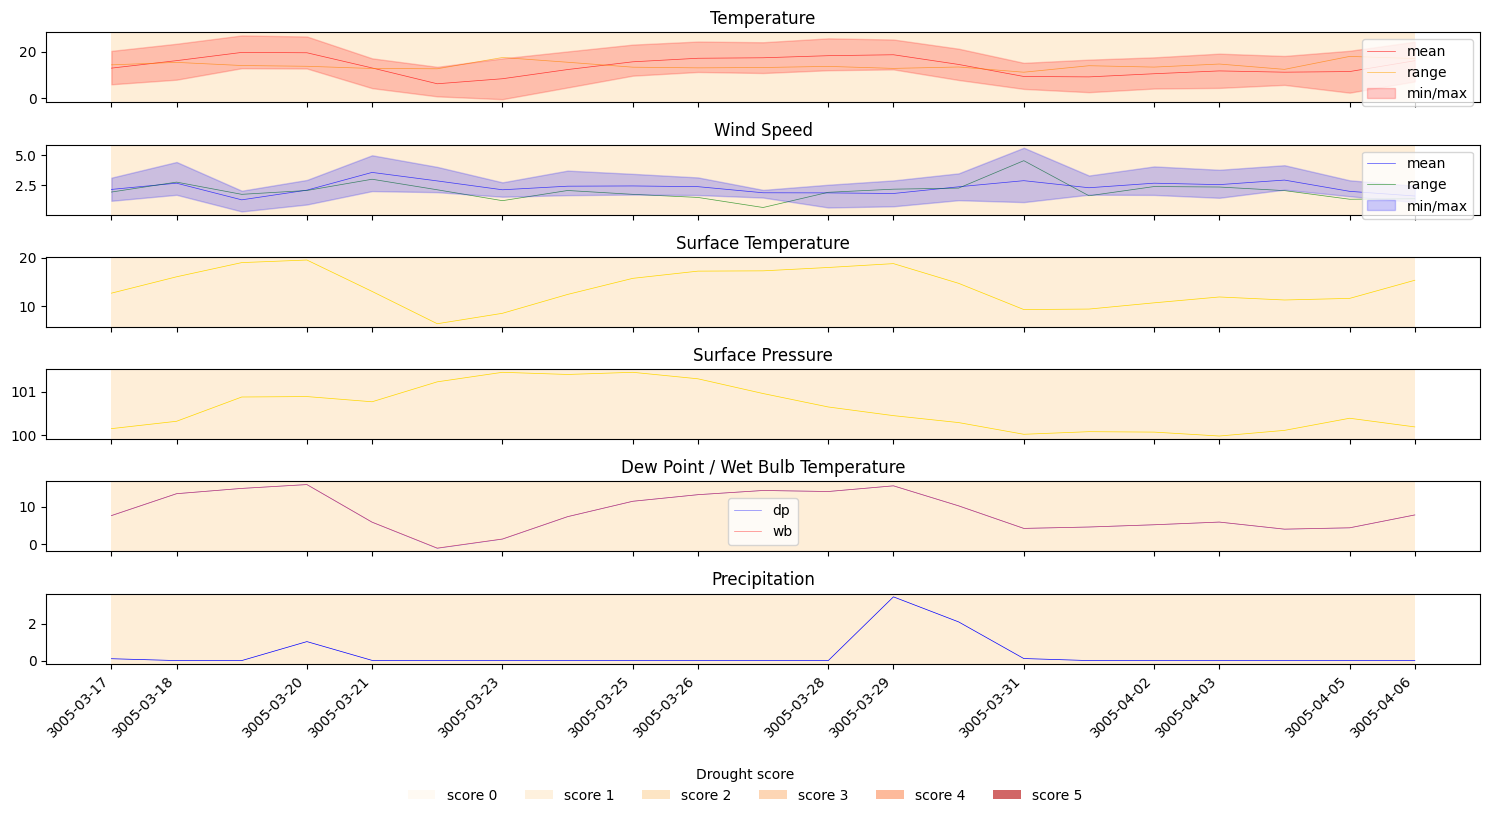

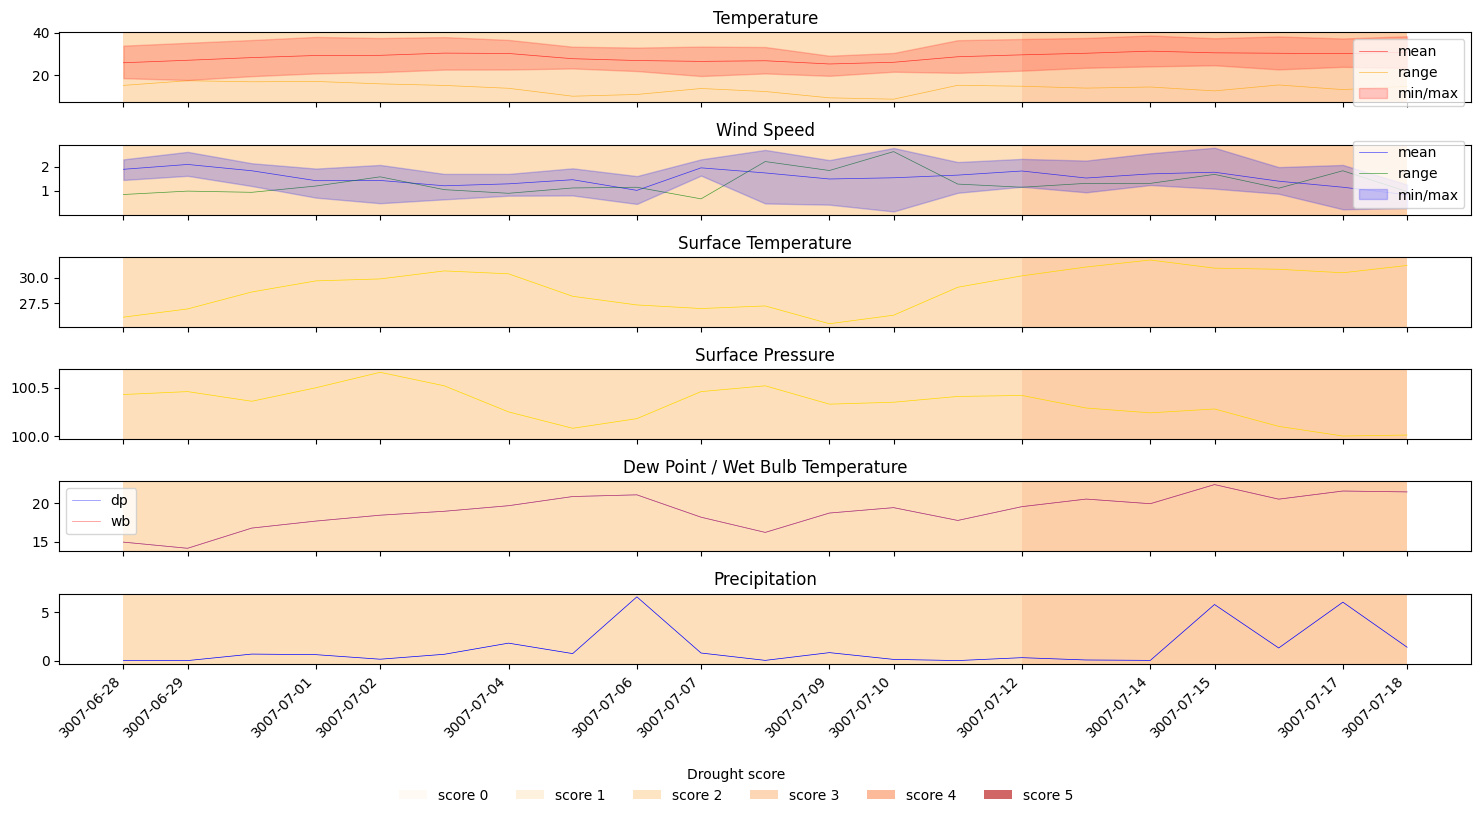

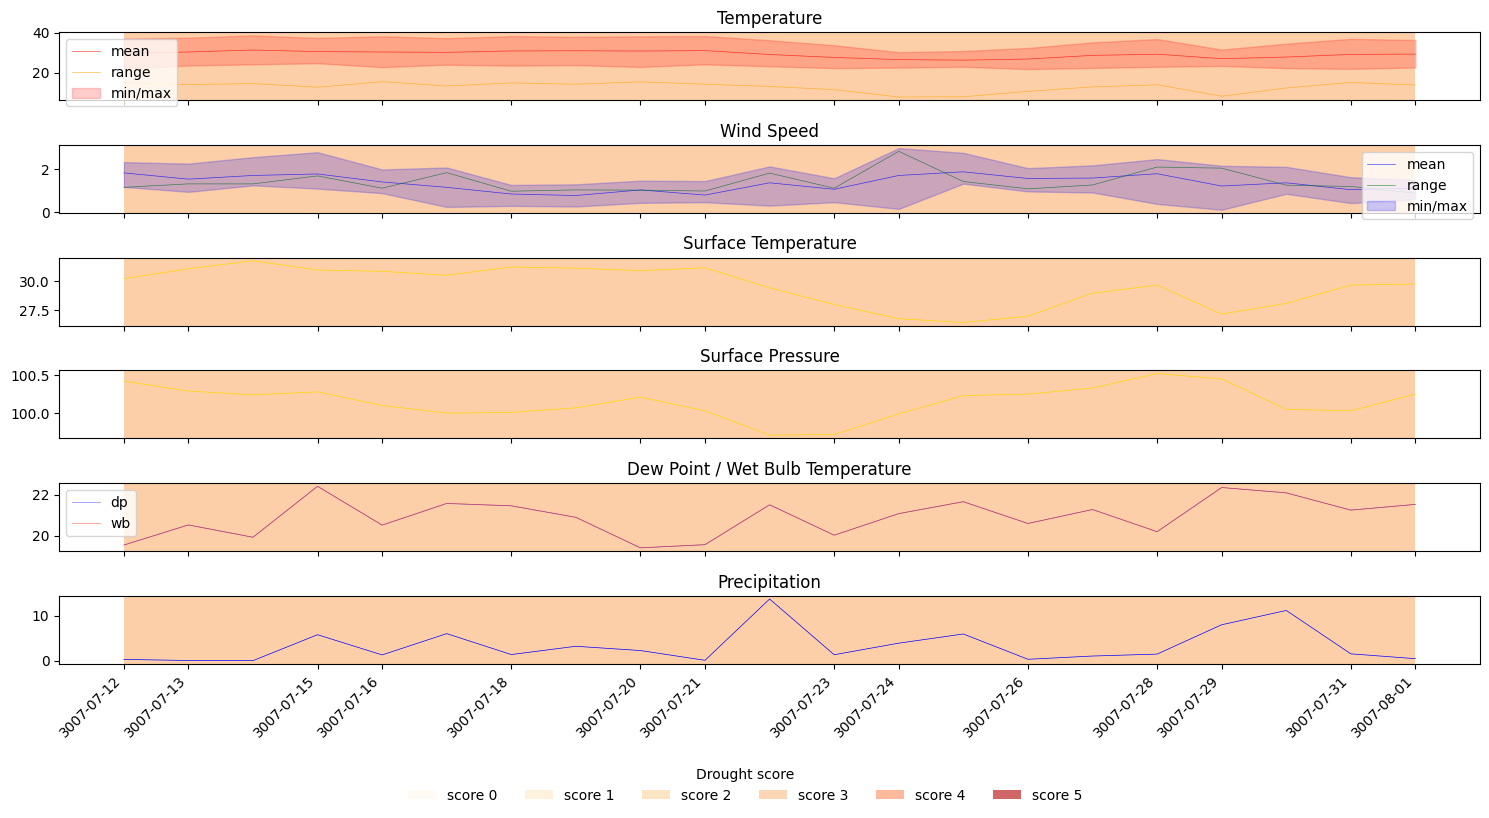

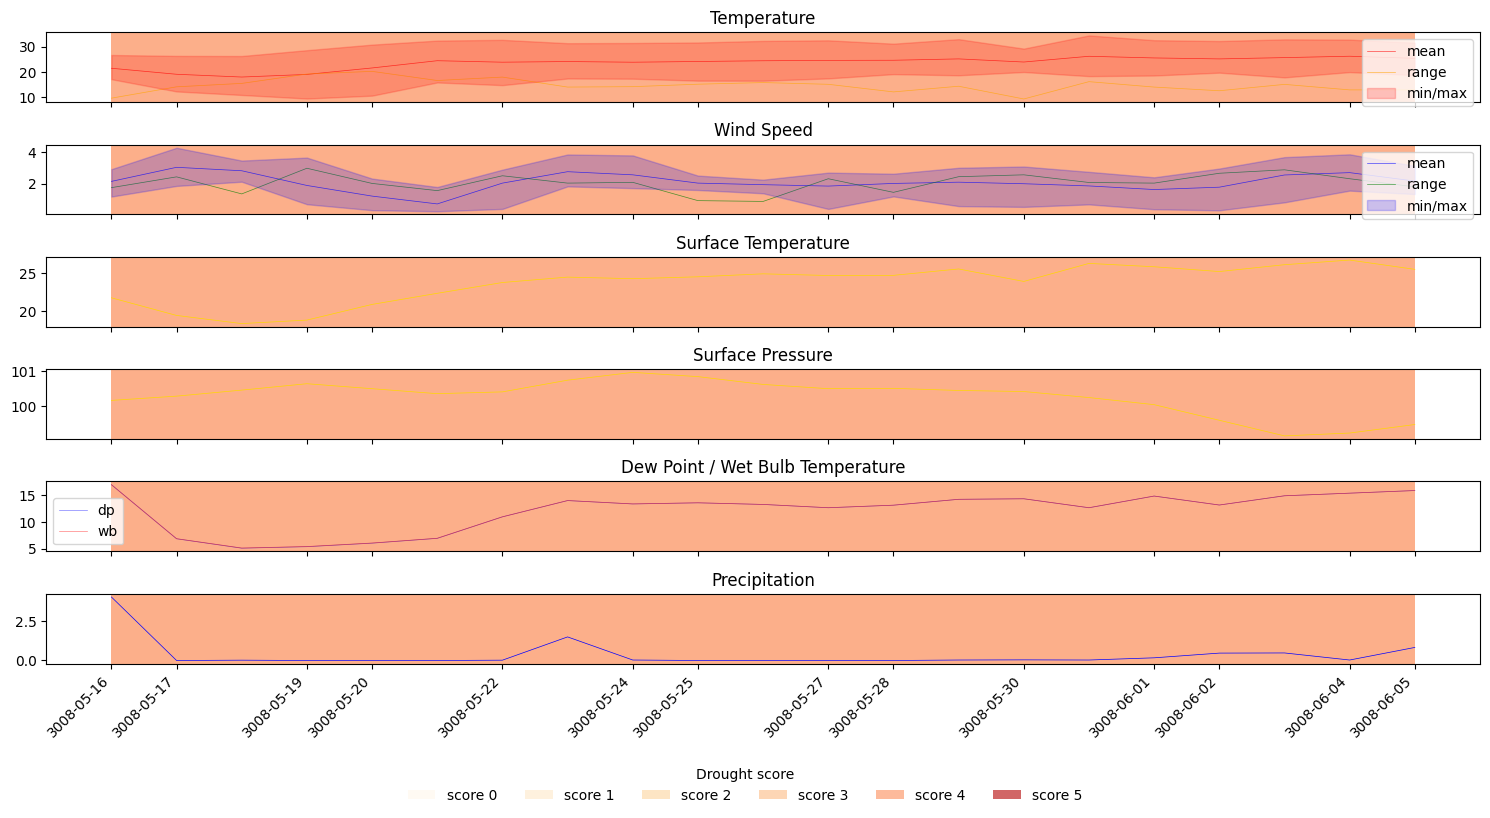

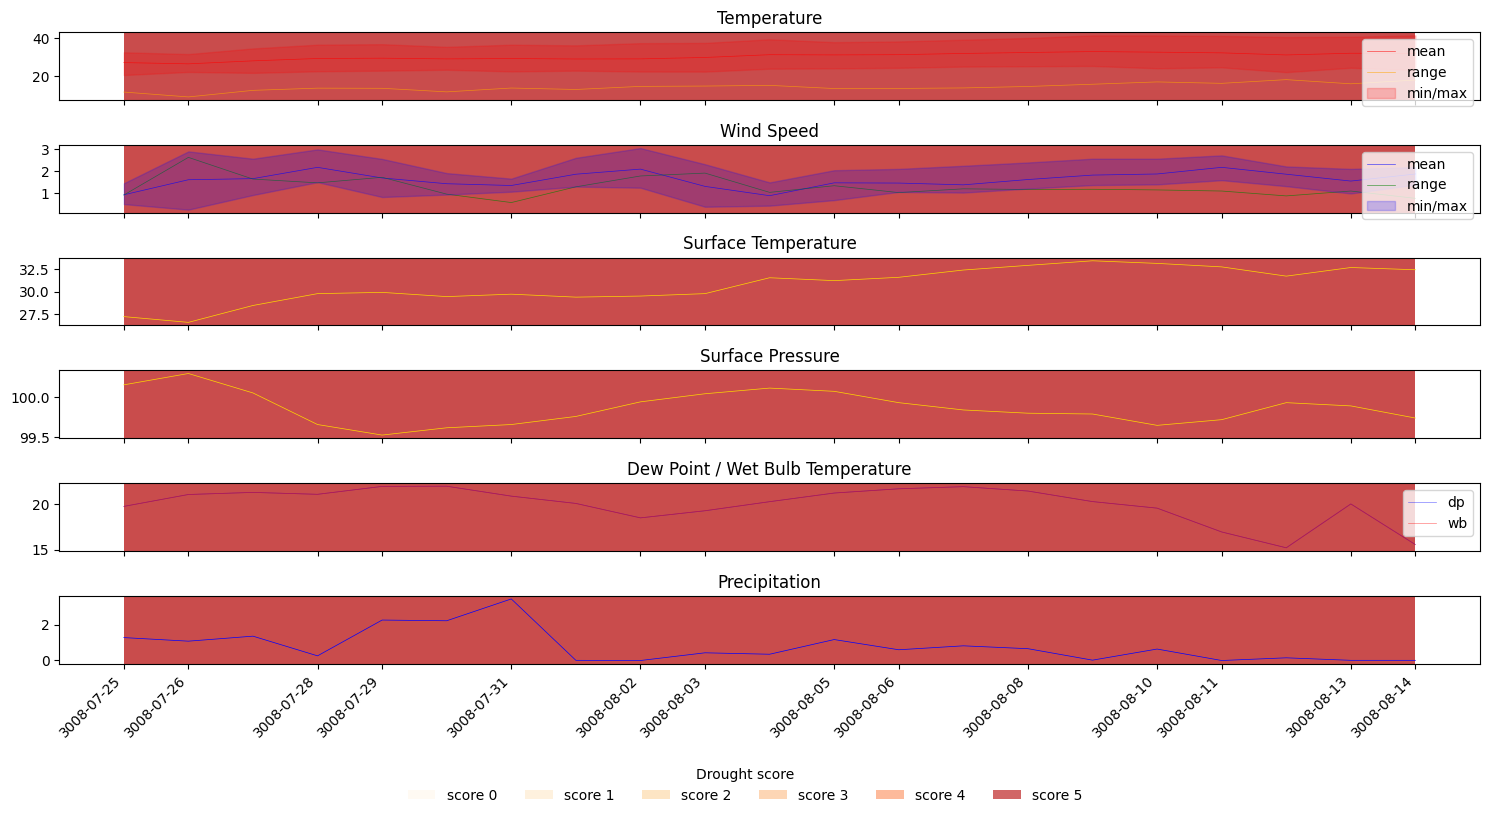

In [32]:
for i in range(6):
    data_frame_to_figures(df_list[i])